# Knocking as optimal stopping

Our previous rule was knock iff EV_knock > a flat constant kappa.
This notebook replaces it with the EV of not knocking and playing on (just like American Options).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../..'))     # repo root from notebooks/policy/

from agent.cards import Card, make_deck, RANKS, SUITS
from agent.inference import BeliefState
# Validated one-ply machinery — reused, not re-derived:
from agent.policy.knock import knock_discard, knock_distribution, sample_opp_hands
from agent.policy import ProbabilisticPolicy            # base class for the search bot (sec 11)
from agent.policy.search import _knock_gain, _rollout   # engine-faithful knock gain; naive playout
from agent.policy._meldcache import best_melds          # best meld decomposition (discard search)

DECK = make_deck()
RNG  = np.random.default_rng(0)

## 1. The objective: what are we really optimizing?

The earlier eval ranked policies on win rate and concluded the policy layer was a dead end, noting kappa as 'inert'. However, we should reconsider whether its effects on the final score can be within statistical significance. Gin rummy isn't just played once. Just like in trading, if your win rate is 50/50 but your winners are bigger than your losers, you come out on top!

So we should judge the knock on expected points per hand, not win rate.

## 2. The knock decision
The rule we will be replacing; knock when you can!

In [2]:
# EV_knock: the validated knock distribution (EV, P(undercut), k, discard) or None if illegal.
def ev_knock(hand, bs, n=1500, rng=RNG):
    return knock_distribution(hand, bs, n, rng)

# The myopic rule we are replacing: knock iff EV_knock beats a flat constant kappa.
def should_knock_myopic(hand, bs, kappa=0.0, n=1500, rng=RNG):
    r = ev_knock(hand, bs, n, rng)
    return (r is not None) and (r['ev'] > kappa)

# A marginal-but-legal hand (best kept deadwood k = 10), reused throughout the notebook.
OWN = [Card('7','H'), Card('8','H'), Card('9','H'),                 # heart run
       Card('5','C'), Card('5','D'), Card('5','S'),                 # fives set
       Card('A','C'), Card('2','D'), Card('3','C'), Card('4','D'),  # low deadwood
       Card('9','S')]                                               # the throwaway
k0, disc0, _ = knock_discard(OWN)
print(f'best kept deadwood k = {k0},  knock-discard = {disc0}')

best kept deadwood k = 10,  knock-discard = 9S


## 3. Determinized worlds

We use Madow sampling to create worlds consistent with our belief state like with the discards.

In [3]:
def determinize(bs, n_worlds, rng):
    p = np.array([bs.prob(c) for c in DECK])
    uncertain = [DECK[i] for i in np.where((p > 1e-12) & (p < 1 - 1e-9))[0]]
    worlds = []
    for opp in sample_opp_hands(bs, n_worlds, rng):
        held = set(opp)
        stock = [c for c in uncertain if c not in held]
        rng.shuffle(stock)
        worlds.append((opp, stock))
    return worlds

_bs_demo = BeliefState(OWN[:10], Card('Q','S'))
_w = determinize(_bs_demo, 3, np.random.default_rng(1))
print('sampled stock size per world:', [len(s) for _, s in _w])

sampled stock size per world: [31, 31, 31]


## 4. Why naive continuation acts like greedy.

The naive base policy for determinization knocks the instant it's legal. As such, when we determinize we just push the decision one step forwards so effectively once its legal we just knock on the second turn. So `EV_knock` ~ `EV_continue`.

In [4]:
def continuation_naive(hand, bs, n_det=80, rng=RNG):
    # Hold the knock-discard's kept 10 but DON'T knock; play the world forward
    # with the naive base policy. It's the opponent's move right after we discard.
    k, discard, _ = knock_discard(hand)
    kept = [c for c in hand if c is not discard]
    worlds = determinize(bs, n_det, rng)
    vals = [_rollout(kept, opp, list(stock), me_to_move=False) for opp, stock in worlds]
    return float(np.mean(vals))

_bs = BeliefState(OWN[:10], Card('Q','S'))
_r = ev_knock(OWN, _bs)
print(f'EV_knock           = {_r["ev"]:.2f}')
print(f'EV_continue(naive) = {continuation_naive(OWN, _bs):.2f}   '
      f'<- tracks EV_knock: the naive playout knocks immediately, so waiting looks free')

EV_knock           = 50.12
EV_continue(naive) = 48.24   <- tracks EV_knock: the naive playout knocks immediately, so waiting looks free


## 5. A deferring continuation playout

To combat that issue: we defer knocking to chase a lower `k` (or gin).

In [5]:
def rollout_defer(me, opp, stock, me_to_move, patience):
    """One determinized world, deferring continuation policy.
    me: draw stock, recompute best k; knock only on gin (k==0), or once forced
        (patience turns used up, or stock nearly gone) and k<=10.
    opp: knock at first legal -> the threat we bear by waiting.
    Signed score from me's perspective."""
    me, opp = list(me), list(opp)
    my_turns = 0
    while stock:
        if me_to_move:
            me.append(stock.pop())
            k, d, melds = knock_discard(me); me.remove(d)
            my_turns += 1
            forced = (len(stock) <= 2) or (my_turns >= patience)
            if k == 0 or (forced and k <= 10):
                return _knock_gain(melds, k, opp)
            # else: keep our 10 best and play on (do not knock)
        else:
            opp.append(stock.pop())
            k, d, melds = knock_discard(opp); opp.remove(d)
            if k <= 10:                      # opponent cashes out the moment it can
                return -_knock_gain(melds, k, me)
        me_to_move = not me_to_move
    return 0                                  # stock exhausted -> no result

def continuation_value(hand, bs, patience=4, n_det=150, rng=RNG):
    """EV of declining to knock now and playing on, over determinized worlds."""
    k, discard, _ = knock_discard(hand)
    kept = [c for c in hand if c is not discard]
    worlds = determinize(bs, n_det, rng)
    vals = [rollout_defer(kept, opp, list(stock), me_to_move=False, patience=patience)
            for opp, stock in worlds]
    return float(np.mean(vals))

## 6. When they differ

The myopic rule (kappa=0) knocks whenever knocking is +EV, so in the near-gin case it cashes out a thin +5 straight into the opponent's undercut.

In [6]:
def should_knock_optimal(hand, bs, patience=4, n_det=150, n_knock=1500, rng=RNG):
    r = ev_knock(hand, bs, n_knock, rng)
    if r is None:
        return False, None                         # not legal to knock
    cv = continuation_value(hand, bs, patience, n_det, rng)
    return r['ev'] >= cv, {'ev_knock': r['ev'], 'undercut': r['undercut'], 'ev_continue': cv}

def scenario(obs, label, rng):
    bs = BeliefState(OWN[:10], Card('Q','S'))
    for c in obs:
        bs.observe_opponent_draw_discard_bayesian(c, nu=2.5)  # opp visibly collects these
    knock, info = should_knock_optimal(OWN, bs, rng=rng)
    myopic = should_knock_myopic(OWN, bs, kappa=0.0, rng=rng)
    print(f'{label:22s} EV_knock={info["ev_knock"]:6.2f}  undercut={info["undercut"]:.2f}  '
          f'EV_cont={info["ev_continue"]:6.2f}  optimal={"KNOCK" if knock else "WAIT "}  '
          f'myopic(kappa=0)={"KNOCK" if myopic else "WAIT"}')

rng = np.random.default_rng(11)
# blind belief: opponent far -> cashing out the big lead is right
scenario([], 'blind (far)', rng)
# informed belief: opponent visibly near-gin on low cards -> our knock EV collapses,
# undercut risk rises; optimal stopping waits where the flat rule would still knock.
scenario([Card('A','D'),Card('2','C'),Card('3','S'),Card('A','H'),Card('A','S'),Card('2','S')],
         'opp near-gin (low)', rng)

blind (far)            EV_knock= 49.78  undercut=0.00  EV_cont= 32.51  optimal=KNOCK  myopic(kappa=0)=KNOCK
opp near-gin (low)     EV_knock=  4.99  undercut=0.09  EV_cont=  7.13  optimal=WAIT   myopic(kappa=0)=KNOCK


## 7. How often does it disagree with knock-when-legal?

The divergences are the deals where the state-dependent threshold matters (i.e Deadwood=1).

In [7]:
# Random 11-card deals are almost never legal-to-knock, so construct hands that
# ARE: two disjoint melds + low deadwood, keeping best kept-deadwood k in 1..10.
def _random_meld(rng, used):
    for _ in range(200):
        if rng.random() < 0.5:                                  # set
            r = RANKS[rng.integers(len(RANKS))]; ss = list(SUITS); rng.shuffle(ss)
            m = [Card(r, s) for s in ss[:3]]
        else:                                                   # run
            s = SUITS[rng.integers(len(SUITS))]; i = rng.integers(len(RANKS) - 2)
            m = [Card(RANKS[i + k], s) for k in range(3)]
        if not any(c in used for c in m):
            return m
    return None

def knockable_hand(rng):
    for _ in range(100):
        used = set(); m1 = _random_meld(rng, used)
        if not m1: continue
        used |= set(m1); m2 = _random_meld(rng, used)
        if not m2: continue
        used |= set(m2)
        lows = [c for c in DECK if c.value <= 4 and c not in used]; rng.shuffle(lows)
        hand = m1 + m2 + lows[:5]
        if len(hand) != 11: continue
        k, _, _ = knock_discard(hand)
        if 1 <= k <= 10:                       # skip trivial gin (k==0) and illegal (k>10)
            return hand
    return None

def random_belief(hand, rng):
    # Blind, or an opponent visibly collecting a few low cards (raises undercut risk).
    face_up = next(c for c in DECK if c not in set(hand))
    bs = BeliefState(hand[:10], face_up)
    seen = set(hand[:10]) | {face_up}
    obs = [c for c in DECK if c.value <= 4 and c not in seen]; rng.shuffle(obs)
    for c in obs[:rng.integers(0, 5)]:        # 0..4 observed opponent pickups
        bs.observe_opponent_draw_discard_bayesian(c, nu=2.5)
    return bs

# Small samples for a quick pass; raise N_DECISIONS / n_det / n_knock for a tighter estimate.
rng = np.random.default_rng(99)
N_DECISIONS = 20
agree = disagree = n = 0
examples = []
while n < N_DECISIONS:
    hand = knockable_hand(rng)
    if hand is None: continue
    bs = random_belief(hand, rng)
    opt, info = should_knock_optimal(hand, bs, n_det=24, n_knock=200, rng=rng)
    if info is None: continue
    myo = info['ev_knock'] > 0.0              # myopic kappa=0
    n += 1
    if opt == myo:
        agree += 1
    else:
        disagree += 1
        if len(examples) < 6:
            k, _, _ = knock_discard(hand)
            examples.append((k, round(info['ev_knock'], 1), round(info['ev_continue'], 1),
                             'KNOCK' if opt else 'WAIT'))
print(f'knockable decisions: {n}   agree={agree}   disagree={disagree}'
      f'   ({100*disagree/max(n,1):.0f}% disagreement)')
print('disagreement examples (k, EV_knock, EV_cont, optimal):')
for e in examples: print('  ', e)

knockable decisions: 20   agree=17   disagree=3   (15% disagreement)
disagreement examples (k, EV_knock, EV_cont, optimal):
   (1, 38.5, 42.6, 'WAIT')
   (1, 27.0, 28.0, 'WAIT')
   (1, 35.6, 38.9, 'WAIT')


## 8. The real test: optstop vs a tuned kappa

We sweep a constant `kappa` on the paired margin metric and overlay optstop. If the best `kappa` overlaps optstop within SE, the rollout collapses to that constant (drop it). If optstop sits above the whole curve, `EV_continue` carries state info beyond `EV_knock` and the state-dependence is real value.

In [8]:
# Paired margin machinery + register the optstop variant ('prob_optstop').
import agent.eval.harness as H
from agent.eval.harness import _play_indexed, _points_to

class OptStopPolicy(ProbabilisticPolicy):
    def __init__(self, *a, n_det=24, patience=4, **kw):
        super().__init__(*a, **kw); self.n_det, self.patience = n_det, patience
    def should_knock(self, hand, bs):
        r = knock_distribution(hand, bs, self.knock_samples, self.rng)
        if r is None: return False
        return r['ev'] >= continuation_value(hand, bs, self.patience, self.n_det, self.rng)

H.POLICY_REGISTRY['prob_optstop'] = (lambda **kw: OptStopPolicy(
    alpha=kw.get('alpha',0.1), gamma=kw.get('gamma',0.0), kappa=kw.get('kappa',0.0),
    knock_samples=kw.get('knock_samples',150), n_det=kw.get('n_det',24), seed=kw.get('seed')), True)

def margins(subject_kind, n, ks=150, seed0=0, params=None):
    """Signed points/hand for `subject_kind` (seat 0) vs the probabilistic baseline,
    one entry per deal. Same seeds across calls -> identical deals (paired)."""
    p = {'knock_samples': ks}
    if params: p.update(params)
    opp = ('probabilistic', {'knock_samples': ks})
    return np.array([_points_to(_play_indexed((subject_kind, p), opp,
                                              seed=seed0 + i, sub_seat=0), 0)
                     for i in range(n)])

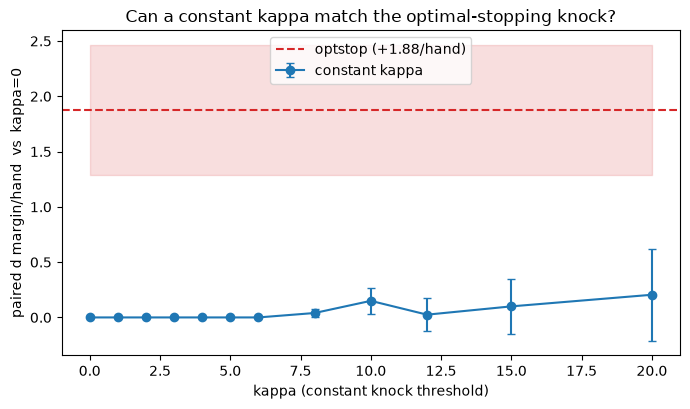

best constant kappa = 20  ->  margin +0.20 +/- 0.42
optstop                ->  margin +1.88 +/- 0.59
overlap within SE -> optstop reduces to that kappa (drop the rollout);
optstop above the whole curve -> state-dependence is real value.


In [9]:
N_SWEEP, KS = 200, 150
ref = margins('probabilistic', N_SWEEP, KS, params={'kappa': 0.0})   # reference arm

def paired_gain(kind, params=None):
    d = margins(kind, N_SWEEP, KS, params=params) - ref
    return d.mean(), d.std(ddof=1) / np.sqrt(N_SWEEP)

kappas = [0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
sweep = [paired_gain('probabilistic', {'kappa': float(k)}) for k in kappas]
g_k  = np.array([m for m, _ in sweep])
se_k = np.array([s for _, s in sweep])
g_opt, se_opt = paired_gain('prob_optstop')

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(kappas, g_k, yerr=se_k, fmt='o-', capsize=3, label='constant kappa')
ax.axhline(g_opt, color='C3', ls='--', label=f'optstop ({g_opt:+.2f}/hand)')
ax.fill_between([min(kappas), max(kappas)], g_opt - se_opt, g_opt + se_opt,
                color='C3', alpha=0.15)
ax.set_xlabel('kappa (constant knock threshold)')
ax.set_ylabel('paired d margin/hand  vs  kappa=0')
ax.set_title('Can a constant kappa match the optimal-stopping knock?')
ax.legend(); plt.tight_layout(); plt.show()

best = int(np.argmax(g_k))
print(f'best constant kappa = {kappas[best]:>2}  ->  margin {g_k[best]:+.2f} +/- {se_k[best]:.2f}')
print(f'optstop                ->  margin {g_opt:+.2f} +/- {se_opt:.2f}')
print('overlap within SE -> optstop reduces to that kappa (drop the rollout);')
print('optstop above the whole curve -> state-dependence is real value.')

## 9. Summary

The optimal-stopping knock barely moves the win rate — on that metric it's parity, the same verdict this project kept reaching. But chasing it forced the realization that win rate was the wrong objective: gin is played to a points target, so what matters is expected points per hand, and small frequent edges compound.

In futue: we will optimize and report **points margin with its paired SE**, and treat win rate as a diagnostic.